## This notebook contains codes executed to implement and analyze two GAN variants (Task1: WGAN-GP and Task2: Conditional WGAN-GP) on CelebA.

# Task 2 — Conditional WGAN-GP on CelebA 64×64

**Attribute:** Eyeglasses  (assigned because name starts with S)

**Conditioning strategy:**
- **Generator** — label embedding concatenated with z before the first ConvTranspose layer
- **Critic** — label projected to a (1, H, W) spatial map, appended as a 4th input channel

**Outputs written to** `./outputs_cond/`:
```
checkpoints/              model weights
samples/grid_*.png        periodic sample grids (top half label=0, bottom half label=1)
samples/samples_final_50.png      25 no-glasses + 25 glasses
samples/fixed_z_comparison.png    same z, label 0 vs label 1
samples/interpolation_cond.png    z1→z2, label fixed at 1
training_curves.png
losses.json
```

## 1 · Environment setup

In [ ]:
import torch
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
    print('VRAM    :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM    : 102.0 GB


## 2 · Clone from GitHub & install dependencies

In [ ]:
import os, sys

GITHUB_REPO = 'https://github.com/mehrosejaved/gan_variants.git'

REPO_NAME  = GITHUB_REPO.rstrip('/').split('/')[-1].replace('.git', '')
CLONE_DIR  = f'/content/{REPO_NAME}'
TASK1_DIR  = os.path.join(CLONE_DIR, 'wgan_gp')           # shared utils live here
TASK2_DIR  = os.path.join(CLONE_DIR, 'conditional_wgan_gp')

if not os.path.exists(CLONE_DIR):
    os.system(f'git clone {GITHUB_REPO} {CLONE_DIR}')
    print(f'Cloned → {CLONE_DIR}')
else:
    os.system(f'git -C {CLONE_DIR} pull')
    print(f'Pulled latest → {CLONE_DIR}')

os.system(f'pip install -q -r {TASK2_DIR}/requirements.txt')

# Both task dirs on path: task2 first (cond_models etc.),
# then task1 (dataset.py, utils.py)
sys.path.insert(0, TASK1_DIR)
sys.path.insert(0, TASK2_DIR)
os.chdir(TASK2_DIR)
print('Working dir:', os.getcwd())
print('Files      :', os.listdir('.'))

Cloned → /content/gan_variants
Working dir: /content/gan_variants/conditional_wgan_gp
Files      : ['requirements.txt', 'cond_models.py', 'cond_train.py', 'wgan_gp_task2.ipynb']


In [ ]:
# Check file structure
import os

for root, dirs, files in os.walk('/content/gan_variants'):
    for name in files:
        if 'dataset' in name.lower():
            print(os.path.join(root, name))

/content/gan_variants/wgan_gp/dataset.py


## 3 · CelebA dataset setup

In [ ]:
# Download with Kaggle:
!kaggle datasets download -d jessicali9530/celeba-dataset -p ./data --unzip
DATA_ROOT = './data'

import os
print('DATA_ROOT  :', DATA_ROOT)
print('Exists     :', os.path.exists(DATA_ROOT))

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:06<00:00, 229MB/s]

DATA_ROOT  : ./data
Exists     : True


In [ ]:
# Sanity check — should return (images, labels) pairs
from dataset import get_celeba_loader
import torchvision.utils as vutils
import matplotlib.pyplot as plt

loader = get_celeba_loader(
    root=DATA_ROOT, split='train',
    batch_size=16, num_workers=2,
    attr_name='Eyeglasses', max_samples=512,
)
imgs, labels = next(iter(loader))
print('Image shape  :', imgs.shape)
print('Label shape  :', labels.shape)
print('Label values :', labels.tolist())
print(f'Glasses: {labels.sum().item()} / {len(labels)} in this batch')

[KaggleCelebA] images    : data/img_align_celeba/img_align_celeba
[KaggleCelebA] attrs     : data/list_attr_celeba.csv
[KaggleCelebA] partition : data/list_eval_partition.csv
[KaggleCelebA] split='train' → 162,770 images
Image shape  : torch.Size([16, 3, 64, 64])
Label shape  : torch.Size([16])
Label values : [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
Glasses: 2 / 16 in this batch


## 4 · Model sanity check

In [ ]:
import torch
from cond_models import ConditionalGenerator, ConditionalCritic, weights_init

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
B = 4

G = ConditionalGenerator(latent_dim=128, embed_dim=32, num_classes=2, feature_maps=64).to(device)
D = ConditionalCritic(embed_dim=32, num_classes=2, feature_maps=64).to(device)
G.apply(weights_init); D.apply(weights_init)

z      = torch.randn(B, 128, device=device)
labels = torch.randint(0, 2, (B,), device=device)
imgs   = G(z, labels)
scores = D(imgs, labels)

print(f'G output : {imgs.shape}   range [{imgs.min():.2f}, {imgs.max():.2f}]')
print(f'D output : {scores.shape}')
print(f'G params : {sum(p.numel() for p in G.parameters()):,}')
print(f'D params : {sum(p.numel() for p in D.parameters()):,}')

G output : torch.Size([4, 3, 64, 64])   range [-0.78, 0.81]
D output : torch.Size([4])
G params : 4,068,288
D params : 2,901,824


## 5 · Training configuration

In [ ]:
from cond_train import CondConfig

cfg = CondConfig(
    data_root     = DATA_ROOT,
    attr_name     = 'Eyeglasses',
    max_samples   = None,
    latent_dim    = 128,
    embed_dim     = 32,
    num_classes   = 2,
    feature_maps  = 64,
    num_epochs    = 20,
    batch_size    = 64,
    n_critic      = 5,
    lambda_gp     = 10.0,
    lr            = 1e-4,
    adam_b1       = 0.0,
    adam_b2       = 0.9,
    output_dir    = './outputs_cond',
    sample_interval = 200,
    ckpt_interval = 5,
    num_workers   = 2,
    seed          = 42,
)
print(cfg)

CondConfig(data_root='./data', attr_name='Eyeglasses', max_samples=None, latent_dim=128, embed_dim=32, num_classes=2, feature_maps=64, num_epochs=20, batch_size=64, n_critic=5, lambda_gp=10.0, lr=0.0001, adam_b1=0.0, adam_b2=0.9, output_dir='./outputs_cond', sample_interval=200, ckpt_interval=5, num_workers=2, seed=42)


## 6 · Run training

In [ ]:
from cond_train import train

train(cfg, resume_from=None)

Device     : cuda
Attribute  : Eyeglasses
Epochs     : 20  |  Batch : 64  |  n_critic : 5
[KaggleCelebA] images    : data/img_align_celeba/img_align_celeba
[KaggleCelebA] attrs     : data/list_attr_celeba.csv
[KaggleCelebA] partition : data/list_eval_partition.csv
[KaggleCelebA] split='train' → 162,770 images
Dataset    : 162,770 images  →  2,543 batches/epoch
G params   : 4,068,288
D params   : 2,901,824
Epoch [001/20]  Step    50  |  D: -44.0639  G: +80.3095  GP: 1.5164
Epoch [001/20]  Step   100  |  D: -23.2577  G: +85.2183  GP: 0.7128
Epoch [001/20]  Step   150  |  D: -20.3319  G: +80.5449  GP: 0.4470
[save_image_grid] saved → outputs_cond/samples/grid_000200.png
Epoch [001/20]  Step   200  |  D: -16.6040  G: +85.0686  GP: 0.3662
Epoch [001/20]  Step   250  |  D: -15.2164  G: +80.7282  GP: 0.3402
Epoch [001/20]  Step   300  |  D: -17.2288  G: +90.9045  GP: 0.2414
Epoch [001/20]  Step   350  |  D: -14.5660  G: +90.2706  GP: 0.3241
[save_image_grid] saved → outputs_cond/samples/grid_

## 7 · Training curves

Total G steps: 10172
[plot_training_curves] saved → outputs_cond/training_curves.png


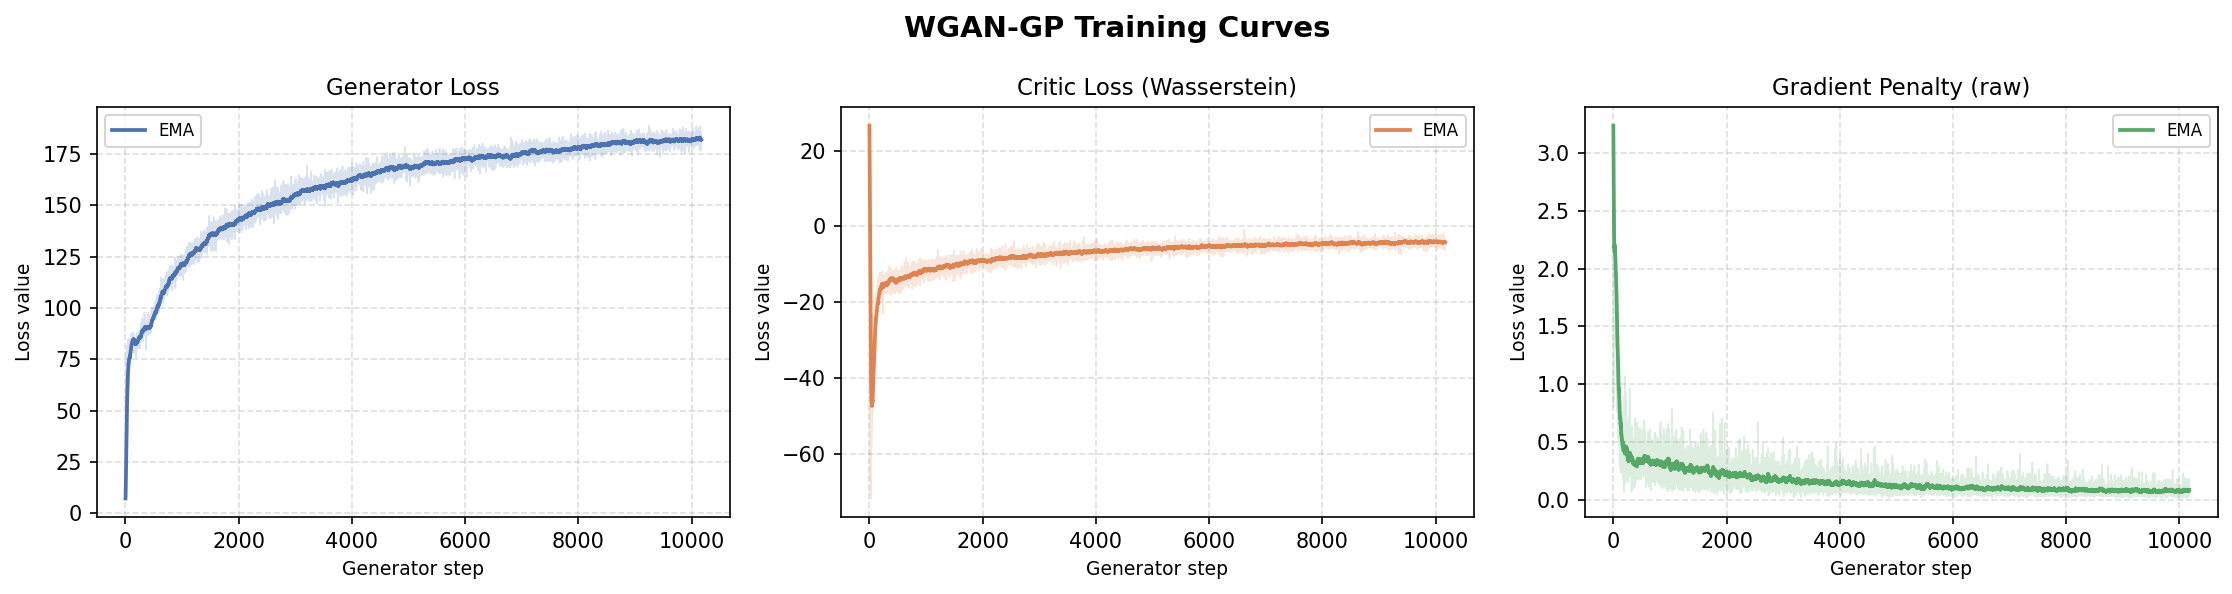

In [ ]:
%matplotlib inline
from utils import LossTracker, plot_training_curves
from IPython.display import Image as IPImage, display

tracker = LossTracker.load('./outputs_cond/losses.json')
print(f'Total G steps: {len(tracker)}')

plot_training_curves(tracker, save_path='./outputs_cond/training_curves.png', show=False)
display(IPImage('./outputs_cond/training_curves.png'))

## 8 · 50 generated samples (25 no-glasses + 25 glasses)

In [ ]:
%matplotlib inline
import torch, glob, os
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from cond_models import ConditionalGenerator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpts = sorted(glob.glob('./outputs_cond/checkpoints/ckpt_epoch*.pt'))
print('Checkpoints:', [os.path.basename(c) for c in ckpts])

G = ConditionalGenerator(latent_dim=cfg.latent_dim, embed_dim=cfg.embed_dim,
                          num_classes=cfg.num_classes, feature_maps=cfg.feature_maps).to(device)
ckpt = torch.load(ckpts[-1], map_location=device)
G.load_state_dict(ckpt['G'])
G.eval()
print(f'Loaded: {os.path.basename(ckpts[-1])}')

with torch.no_grad():
    z50      = torch.randn(50, cfg.latent_dim, device=device)
    labels50 = torch.cat([torch.zeros(25, dtype=torch.long),
                           torch.ones(25, dtype=torch.long)]).to(device)
    imgs50   = G(z50, labels50)

grid = vutils.make_grid(imgs50, nrow=10, normalize=True, value_range=(-1, 1), padding=2)
plt.figure(figsize=(18, 9))
plt.axis('off')
plt.title('50 Generated CelebA Samples — Conditional WGAN-GP (Eyeglasses)\n'
          'Rows 1–2: no glasses (label=0)  |  Rows 3–5: glasses (label=1)', fontsize=12)
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.tight_layout()
plt.savefig('./outputs_cond/samples/samples_final_50.png', dpi=150, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 9 · Fixed-z comparison: same latent, different label
Each column shares the same `z`. Top row = no glasses (label 0), bottom row = glasses (label 1).

[save_image_grid] saved → ./outputs_cond/samples/fixed_z_comparison.png
  [fixed-z] saved → ./outputs_cond/samples/fixed_z_comparison.png
  Top row    = label 0 (no Eyeglasses)
  Bottom row = label 1 (Eyeglasses)


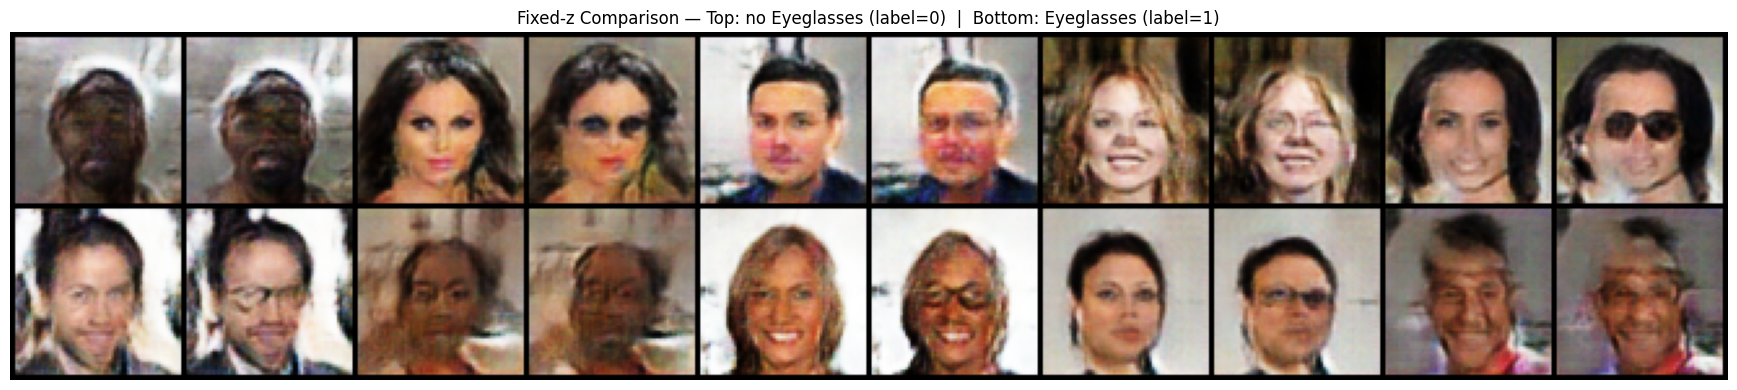

In [ ]:
%matplotlib inline
import torch, matplotlib.pyplot as plt
from cond_train import save_fixed_z_comparison

save_fixed_z_comparison(
    G, device=device, latent_dim=cfg.latent_dim,
    n_samples=10,
    save_path='./outputs_cond/samples/fixed_z_comparison.png',
    seed=cfg.seed,
)

img = plt.imread('./outputs_cond/samples/fixed_z_comparison.png')
plt.figure(figsize=(20, 4))
plt.axis('off')
plt.title('Fixed-z Comparison — Top: no Eyeglasses (label=0)  |  Bottom: Eyeglasses (label=1)',
          fontsize=12)
plt.imshow(img)
plt.tight_layout()
plt.show()

## 10 · Latent interpolation with fixed condition (label = 1, glasses)
z₁ → z₂ with 10 intermediate steps. Condition held fixed at label=1.

[save_image_grid] saved → ./outputs_cond/samples/interpolation_cond.png
  [interp] label=1 fixed, 12 frames → ./outputs_cond/samples/interpolation_cond.png


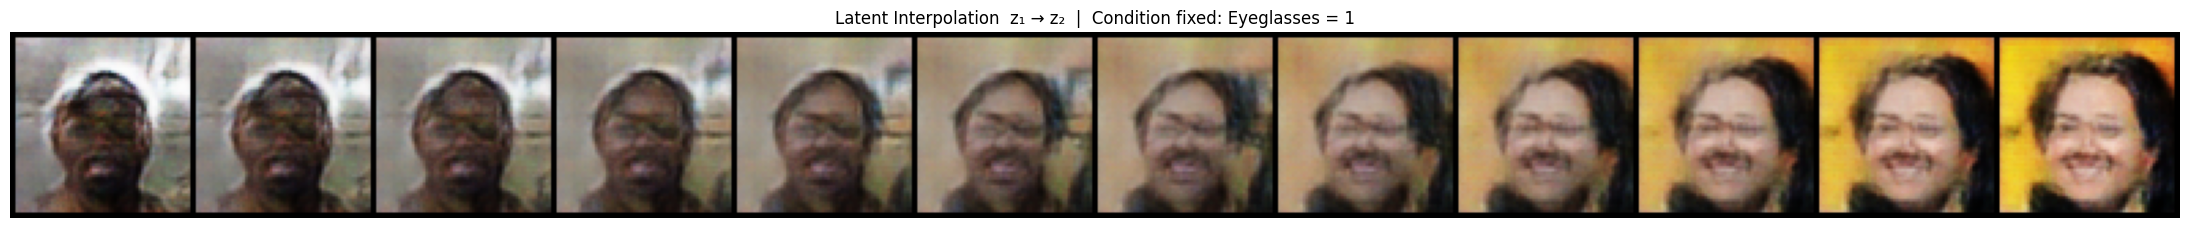

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from cond_train import cond_latent_interpolation

cond_latent_interpolation(
    G, device=device, latent_dim=cfg.latent_dim,
    label=1, n_steps=10,
    save_path='./outputs_cond/samples/interpolation_cond.png',
    seed=cfg.seed,
)

img = plt.imread('./outputs_cond/samples/interpolation_cond.png')
plt.figure(figsize=(22, 3))
plt.axis('off')
plt.title('Latent Interpolation  z₁ → z₂  |  Condition fixed: Eyeglasses = 1', fontsize=12)
plt.imshow(img)
plt.tight_layout()
plt.show()

## 11 · Browse periodic sample grids

In [ ]:
%matplotlib inline
import glob, os, matplotlib.pyplot as plt

grids = sorted(glob.glob('./outputs_cond/samples/grid_*.png'))
print(f'Found {len(grids)} periodic grids')
show_grids = grids[::5] if len(grids) > 5 else grids

fig, axes = plt.subplots(1, len(show_grids), figsize=(5 * len(show_grids), 5))
if len(show_grids) == 1:
    axes = [axes]
for ax, path in zip(axes, show_grids):
    step = os.path.basename(path).replace('grid_', '').replace('.png', '')
    ax.imshow(plt.imread(path))
    ax.set_title(f'step {int(step):,}', fontsize=9)
    ax.axis('off')
plt.suptitle('Conditional generator progress  (top 4 rows = label 0, bottom 4 = label 1)', fontsize=11)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 12 · Download outputs

In [ ]:
import shutil
shutil.make_archive('wgan_gp_cond_outputs', 'zip', './outputs_cond')
from google.colab import files
files.download('wgan_gp_cond_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>